In [5]:

users = {
    "u1": [1,0,1,1,0, 1,0,1,0,1, 1,1,0,0,1, 0,1,1,0,0, 1,0,1,0,1],
    "u2": [0,1,0,0,0, 1,0,1,0,1, 1,1,0,1,1, 0,1,0,1,0, 1,0,1,0,0],
    "u3": [1,1,1,0,0, 1,1,0,0,1, 0,1,1,0,1, 0,0,1,1,0, 1,1,0,0,1],
    "u4": [0,0,1,1,0, 1,0,0,1,1, 1,0,0,1,0, 1,1,0,0,1, 0,1,1,0,0],
    "u5": [1,0,0,1,1, 0,1,1,0,0, 1,1,0,1,0, 0,1,1,0,1, 1,0,0,1,0],
    "u6": [0,0,1,0,0, 1,0,1,0,1, 0,0,0,0,1, 0,1,1,0,0, 1,0,1,0,1],
    "u7": [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0],
    "u8": [1,1,0,1,0, 1,1,0,1,1, 1,0,1,0,0, 0,0,1,1,0, 1,1,0,0,1],
    "u9": [1,1,1,1,1, 1,1,1,1,1, 1,1,1,1,1, 1,1,1,1,1, 1,1,1,1,1],
    "u10": [1,0,0,1,1, 0,1,1,0,0, 1,1,0,1,0, 0,1,1,0,1, 1,0,1,1,1]

}


def validate_vector(v):
    if len(v) != 25:
        return False
    for x in v:
        if x not in (0, 1):
            return False
    return True

def hamming_distance(a, b):
    return sum(x != y for x, y in zip(a, b))

def similarity_score(a, b):
    matches = sum(x == y for x, y in zip(a, b))
    return matches / len(a)



def find_top_5_matches(target, users):
    results = []

    for user_id, vector in users.items():
        dist = hamming_distance(target, vector)
        sim = similarity_score(target, vector)

        results.append({
            "user": user_id,
            "distance": dist,
            "similarity": sim
        })

    # sort by highest similarity
    results.sort(key=lambda x: x["similarity"], reverse=True)

    return results[:5]



target_user = [
    1,1,1,0,0,
    1,0,1,0,1,
    1,1,0,1,1,
    0,1,0,1,0,
    1,0,1,0,0
]



if validate_vector(target_user):
    matches = find_top_5_matches(target_user, users)

    print("\nTop 5 Matches:\n")

    for m in matches:
        print(
            "User:", m["user"],
            "| Similarity:", round(m["similarity"] * 100, 2), "%",
            "| Distance:", m["distance"]
        )
else:
    print("Invalid input vector. Must be 25 binary values.")


Top 5 Matches:

User: u2 | Similarity: 92.0 % | Distance: 2
User: u1 | Similarity: 76.0 % | Distance: 6
User: u6 | Similarity: 68.0 % | Distance: 8
User: u3 | Similarity: 60.0 % | Distance: 10
User: u9 | Similarity: 56.0 % | Distance: 11


You express emotions:
A. Openly
B. Privately
You prefer people who:
A. Stay calm
B. Show emotions openly
You can stay patient when someone vents for long:
A. Yes
B. No
You feel comfortable talking to:
A. New people easily
B. Only after time
You prefer:
A. One-on-one conversations
B. Small groups
After long conversations, you feel:
A. Energized
B. Drained
You start conversations:
A. Easily
B. Hesitantly
You are more:
A. Expressive
B. Reserved

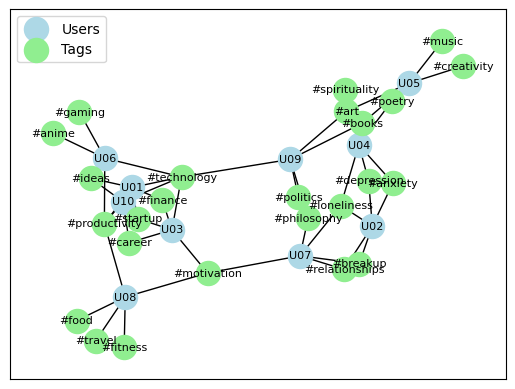

U01 -> ['U10', 'U03', 'U06', 'U08', 'U09']
U02 -> ['U04', 'U07']
U03 -> ['U01', 'U10', 'U06', 'U07', 'U08', 'U09']
U04 -> ['U02', 'U05', 'U07']
U05 -> ['U09', 'U04']
U06 -> ['U01', 'U10', 'U03', 'U08', 'U09']
U07 -> ['U02', 'U03', 'U04', 'U08', 'U09']
U08 -> ['U01', 'U03', 'U06', 'U07', 'U10']
U09 -> ['U05', 'U01', 'U03', 'U06', 'U07', 'U10']
U10 -> ['U01', 'U03', 'U06', 'U08', 'U09']
{'user_id': 'U07', 'matches': [{'matched_user': 'U02', 'score': 0.4286, 'shared_tags': ['breakup', 'loneliness', 'relationships'], 'their_tags': ['anxiety', 'breakup', 'depression', 'loneliness', 'relationships']}, {'matched_user': 'U03', 'score': 0.1111, 'shared_tags': ['motivation'], 'their_tags': ['career', 'finance', 'motivation', 'startup', 'technology']}, {'matched_user': 'U04', 'score': 0.1111, 'shared_tags': ['loneliness'], 'their_tags': ['anxiety', 'depression', 'loneliness', 'poetry', 'spirituality']}, {'matched_user': 'U08', 'score': 0.1111, 'shared_tags': ['motivation'], 'their_tags': ['fitnes

In [8]:
import json
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph):
    pos = nx.spring_layout(graph, seed=42)

    user_nodes = [n for n, a in graph.nodes(data=True) if a["type"] == "user"]
    tag_nodes = [n for n, a in graph.nodes(data=True) if a["type"] == "tag"]

    nx.draw_networkx_nodes(graph, pos, nodelist=user_nodes, node_color='lightblue', label='Users')
    nx.draw_networkx_nodes(graph, pos, nodelist=tag_nodes, node_color='lightgreen', label='Tags')

    nx.draw_networkx_edges(graph, pos)
    nx.draw_networkx_labels(graph, pos, font_size=8)

    plt.legend()
    plt.show()

    
INTEREST_TAGS = [
    "startup", "ideas", "breakup", "depression", "anxiety", "creativity", "music", "books",
    "philosophy", "relationships", "motivation", "career", "loneliness", "gaming", "anime",
    "fitness", "finance", "poetry", "politics", "spirituality", "travel", "technology",
    "art", "food", "productivity"
]


def build_users():
    # Hand-crafted 10 users with overlapping clusters and some zero-overlap pairs
    return [
        {"id": "U01", "interests": ["startup", "ideas", "technology", "productivity", "finance"]},
        {"id": "U02", "interests": ["depression", "anxiety", "loneliness", "breakup", "relationships"]},
        {"id": "U03", "interests": ["startup", "technology", "career", "finance", "motivation"]},
        {"id": "U04", "interests": ["depression", "anxiety", "loneliness", "spirituality", "poetry"]},
        {"id": "U05", "interests": ["music", "art", "creativity", "poetry", "books"]},
        {"id": "U06", "interests": ["gaming", "anime", "technology", "ideas", "productivity"]},
        {"id": "U07", "interests": ["relationships", "breakup", "loneliness", "motivation", "philosophy"]},
        {"id": "U08", "interests": ["fitness", "food", "travel", "motivation", "productivity"]},
        {"id": "U09", "interests": ["politics", "philosophy", "books", "art", "technology"]},
        {"id": "U10", "interests": ["startup", "ideas", "technology", "career", "productivity"]},
    ]

def build_graph(users):
    g = nx.Graph()

    for user in users:
        g.add_node(user["id"], type="user")  # User node with type attribute

    for tag in INTEREST_TAGS:
        g.add_node(f"#{tag}", type="tag")  # Tag node with type attribute

    for user in users:
        user_id = user["id"]
        for tag in user["interests"]:
            g.add_edge(user_id, f"#{tag}", weight=1.0)  # Connect user to tag with weight 1.0

    return g


def add_user_to_graph(graph, user):
    # Add a new user node if it does not exist
    graph.add_node(user["id"], type="user")

    # Add edges for each interest tag the user selected
    for tag in user["interests"]:
        graph.add_node(f"#{tag}", type="tag")  # Ensure tag node exists
        graph.add_edge(user["id"], f"#{tag}", weight=1.0)  # Connect user to tag


def get_user_tags(graph, user_id):
    # Extract tag neighbors by filtering on node type
    return {n for n in graph.neighbors(user_id) if graph.nodes[n].get("type") == "tag"}


def get_matches(user_id, graph, top_n=10):
    tags_a = get_user_tags(graph, user_id)
    results = []

    for node, attrs in graph.nodes(data=True):
        if attrs.get("type") != "user":
            continue  # Skip non-user nodes
        if node == user_id:
            continue  # Skip self

        tags_b = get_user_tags(graph, node)
        intersection = tags_a & tags_b
        if not intersection:
            continue  # Skip zero-overlap users

        union = tags_a | tags_b
        score = len(intersection) / len(union) if union else 0.0  # Guard division by zero

        results.append({
            "matched_user": node,
            "score": round(score, 4),
            "shared_tags": sorted(t[1:] for t in intersection),  # Strip leading '#'
            "their_tags": sorted(t[1:] for t in tags_b),
        })

    results.sort(key=lambda x: x["score"], reverse=True)  # Highest score first

    return {
        "user_id": user_id,
        "matches": results[: min(top_n, len(results))],
    }


def graph_summary(graph):
    tag_nodes = [n for n, a in graph.nodes(data=True) if a.get("type") == "tag"]

    tag_degrees = [
        {"tag": n[1:], "degree": graph.degree(n)}  # Strip leading '#'
        for n in tag_nodes
    ]
    tag_degrees.sort(key=lambda x: x["degree"], reverse=True)  # Most common tags first

    return {
        "total_nodes": graph.number_of_nodes(),
        "total_edges": graph.number_of_edges(),
        "tag_degrees": tag_degrees,
    }


def main():
    users = build_users()
    graph = build_graph(users)
    draw_graph(graph)
    # Collect match results once so we can output a simple summary at the end
    all_results = [get_matches(user["id"], graph) for user in users]

    # Simple per-user output: user id -> similar user ids
    for result in all_results:
        similar_users = [m["matched_user"] for m in result["matches"]]
        print(f"{result['user_id']} -> {similar_users}")

    summary = graph_summary(graph)
    # print(json.dumps(summary, indent=2))
    print(get_matches('U07',graph))

if __name__ == "__main__":
    main()